# 13 — Matching and Propensity Scores for Self-Selected Feature Adoption
**References:** Rosenbaum & Rubin (1983, *Biometrika*) · Stuart (2010, *Statistical Science*) · Imbens & Rubin (2015) Ch. 15, 17-18 · Cunningham (2021) *The Mixtape* Ch. 5

**Prerequisites:** causal_inference_course/05_matching_subclassification.ipynb and
causal_inference_course/06_propensity_scores_ipw.ipynb (full theory: unconfoundedness,
overlap, the Rosenbaum-Rubin theorem, IPW/AIPW — not repeated here).
**Connects to:** causal_inference_course/05_matching_subclassification.ipynb,
causal_inference_course/06_propensity_scores_ipw.ipynb (identification theory this notebook
applies); 12_regression_discontinuity_business.ipynb (an alternative design when a hard
threshold exists instead of free self-selection).

## Narrative thread
```
Business question: did opting in to a new feature cause more engagement?
   -> Users self-select -> naive comparison is confounded
   -> Propensity score estimation -> overlap check -> matching / weighting
   -> Covariate balance diagnostics (love plot, SMD table)
   -> The honest limit: unobserved confounding from self-selection
```

## Why this notebook exists

A huge share of business "causal" questions are not experiments at all: a user turns on a new
notification setting, opts into a beta feature, or subscribes to a premium tier — **on their
own initiative**. Comparing opt-in users to opt-out users directly conflates the treatment
effect with whatever made those users opt in (they may already be more engaged, more price
insensitive, or more tech-savvy). `causal_inference_course/05` and `06` derive the full
matching and propensity-score-weighting machinery; this notebook runs that machinery end to
end on a self-selection business scenario and is explicit about the assumption it rests on:
**unconfoundedness given the covariates we observe** — which self-selection makes especially
easy to violate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.spatial.distance import cdist

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(13)

## Business setting: opting in to a new "smart digest" email

A media app launches an opt-in **weekly smart digest email**. Users choose whether to enable
it in settings. We want to know: does the digest *cause* more weekly active minutes, or do
already-engaged users simply self-select into turning it on?

We simulate four observed covariates that plausibly drive both opt-in and engagement
(tenure, baseline activity, device type, notification-permission status) and one **unobserved**
covariate (intrinsic interest in the app's content) that also drives both — this lets us later
show what happens when unconfoundedness fails.

In [2]:
# ── Simulate users, self-selection into opt-in, and the outcome ──
n = 8000
tenure_months = np.random.exponential(scale=14, size=n).clip(0, 60)
baseline_minutes = np.random.gamma(shape=3.0, scale=25.0, size=n)     # weekly minutes before the launch
android = np.random.binomial(1, 0.55, n)
notif_enabled = np.random.binomial(1, 0.6, n)
unobserved_interest = np.random.normal(0, 1, n)   # NOT available to the analyst

# propensity to opt in depends on observed covariates AND the unobserved trait
logit_p = (
    -1.6 + 0.03 * tenure_months + 0.012 * baseline_minutes
    + 0.35 * notif_enabled - 0.15 * android + 0.55 * unobserved_interest
)
p_optin = 1 / (1 + np.exp(-logit_p))
opted_in = np.random.binomial(1, p_optin)

true_effect = 12.0  # true causal lift in weekly minutes from receiving the digest
post_minutes = (
    baseline_minutes + 0.4 * tenure_months
    + 8 * unobserved_interest              # the unobserved trait also drives future engagement directly
    + true_effect * opted_in
    + np.random.normal(0, 15, n)
)

df = pd.DataFrame({
    "tenure_months": tenure_months, "baseline_minutes": baseline_minutes,
    "android": android, "notif_enabled": notif_enabled, "opted_in": opted_in,
    "post_minutes": post_minutes,
})
df.groupby("opted_in")[["tenure_months", "baseline_minutes", "android", "notif_enabled"]].mean().round(2)

,tenure_months,baseline_minutes,android,notif_enabled
opted_in,,,,
0,11.80,67.03,0.57,0.57
1,16.25,86.35,0.53,0.64


In [3]:
# ── Naive comparison: opted-in vs. opted-out, no adjustment ──
naive_diff = df.loc[df.opted_in == 1, "post_minutes"].mean() - df.loc[df.opted_in == 0, "post_minutes"].mean()
print(f"Naive difference in post-launch minutes: {naive_diff:.2f}  (true effect = {true_effect})")
print("Inflated: opt-in users were already on a higher-engagement trajectory before the digest existed.")

Naive difference in post-launch minutes: 37.17  (true effect = 12.0)
Inflated: opt-in users were already on a higher-engagement trajectory before the digest existed.


## Propensity score estimation

$$e(x) = P(\text{opted\_in}=1 \mid X=x)$$

We estimate $e(x)$ with logistic regression on the **observed** covariates (tenure, baseline
minutes, device, notification status) — deliberately excluding `unobserved_interest`, since a
real analyst never has that variable. This is the crux of the exercise: matching can only ever
condition on what's observed.

In [4]:
ps_model = smf.logit(
    "opted_in ~ tenure_months + baseline_minutes + android + notif_enabled", data=df
).fit(disp=False)
df["pscore"] = ps_model.predict(df)
print(ps_model.summary().tables[1])

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.4513      0.069    -21.004      0.000      -1.587      -1.316
tenure_months        0.0287      0.002     15.381      0.000       0.025       0.032
baseline_minutes     0.0112      0.001     19.447      0.000       0.010       0.012
android             -0.2091      0.047     -4.437      0.000      -0.301      -0.117
notif_enabled        0.3386      0.048      7.046      0.000       0.244       0.433


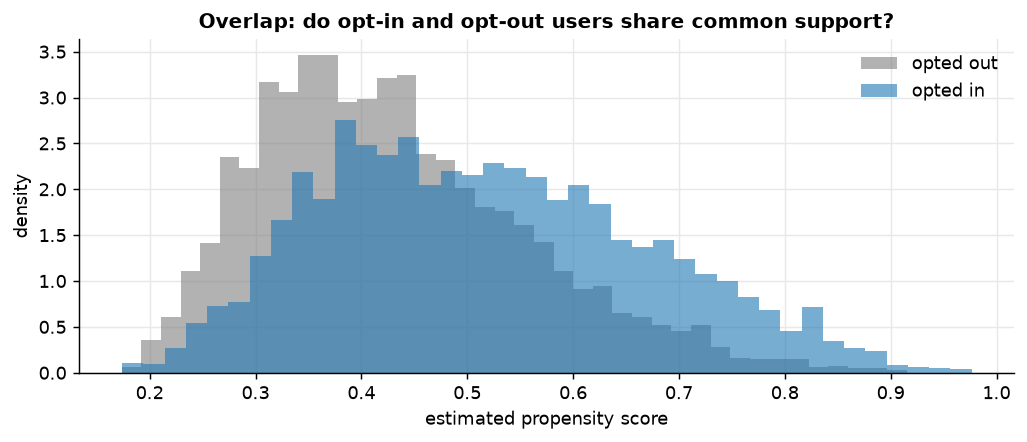

Common support region: [0.174, 0.915]  ->  7987 / 8000 users retained


In [5]:
# ── Overlap check: propensity score distributions by group ──
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(df.loc[df.opted_in == 0, "pscore"], bins=40, alpha=0.6, label="opted out", color="#7f7f7f", density=True)
ax.hist(df.loc[df.opted_in == 1, "pscore"], bins=40, alpha=0.6, label="opted in", color="#1f77b4", density=True)
ax.set_xlabel("estimated propensity score"); ax.set_ylabel("density")
ax.set_title("Overlap: do opt-in and opt-out users share common support?")
ax.legend(); plt.tight_layout(); plt.show()

lo = max(df.loc[df.opted_in == 1, "pscore"].min(), df.loc[df.opted_in == 0, "pscore"].min())
hi = min(df.loc[df.opted_in == 1, "pscore"].max(), df.loc[df.opted_in == 0, "pscore"].max())
in_overlap = df[(df.pscore >= lo) & (df.pscore <= hi)]
print(f"Common support region: [{lo:.3f}, {hi:.3f}]  ->  {len(in_overlap)} / {len(df)} users retained")

## Nearest-neighbor matching on the propensity score

For each opted-in user, find the opted-out user with the closest propensity score (1-NN,
with replacement, restricted to common support).

In [6]:
treated = in_overlap[in_overlap.opted_in == 1].reset_index(drop=True)
control = in_overlap[in_overlap.opted_in == 0].reset_index(drop=True)

dist = cdist(treated[["pscore"]].values, control[["pscore"]].values)
nn_idx = dist.argmin(axis=1)
matched_control = control.iloc[nn_idx].reset_index(drop=True)

matched_att = (treated["post_minutes"].values - matched_control["post_minutes"].values).mean()
print(f"Matched-sample ATT estimate: {matched_att:.2f}  (true effect = {true_effect}, naive = {naive_diff:.2f})")

Matched-sample ATT estimate: 16.91  (true effect = 12.0, naive = 37.17)


## Inverse propensity weighting (IPW), as a cross-check

$$\hat\tau_{ATE} = \frac{1}{n}\sum_i \left(\frac{D_i Y_i}{\hat e(X_i)} - \frac{(1-D_i) Y_i}{1-\hat e(X_i)}\right)$$

In [7]:
w = np.where(df.opted_in == 1, 1 / df.pscore, 1 / (1 - df.pscore))
w = np.clip(w, None, w.quantile(0.99) if hasattr(w, "quantile") else np.percentile(w, 99))  # trim extreme weights
ipw_att = (
    (df.opted_in * df.post_minutes / df.pscore).sum() / (df.opted_in / df.pscore).sum()
    - ((1 - df.opted_in) * df.post_minutes / (1 - df.pscore)).sum() / ((1 - df.opted_in) / (1 - df.pscore)).sum()
)
print(f"IPW estimate: {ipw_att:.2f}  (true effect = {true_effect})")

IPW estimate: 15.86  (true effect = 12.0)


## Covariate balance diagnostics: did matching actually work?

As `causal_inference_course/05` emphasizes, balance checks are **design diagnostics**, done
*before* looking at outcomes: the standardized mean difference (SMD)

$$\text{SMD}_j = \frac{\bar X_{j,\text{treated}} - \bar X_{j,\text{control}}}{\sqrt{(s_{j,\text{treated}}^2 + s_{j,\text{control}}^2)/2}}$$

A common rule of thumb: $|\text{SMD}| < 0.1$ indicates good balance on that covariate.

In [8]:
def smd(x_t, x_c):
    return (x_t.mean() - x_c.mean()) / np.sqrt((x_t.var(ddof=1) + x_c.var(ddof=1)) / 2)

covs = ["tenure_months", "baseline_minutes", "android", "notif_enabled"]
balance = pd.DataFrame({
    "covariate": covs,
    "smd_before": [smd(df.loc[df.opted_in == 1, c], df.loc[df.opted_in == 0, c]) for c in covs],
    "smd_after_matching": [smd(treated[c], matched_control[c]) for c in covs],
})
balance.round(3)

,covariate,smd_before,smd_after_matching
0,tenure_months,0.342,0.001
1,baseline_minutes,0.447,0.001
2,android,-0.087,-0.007
3,notif_enabled,0.149,-0.009


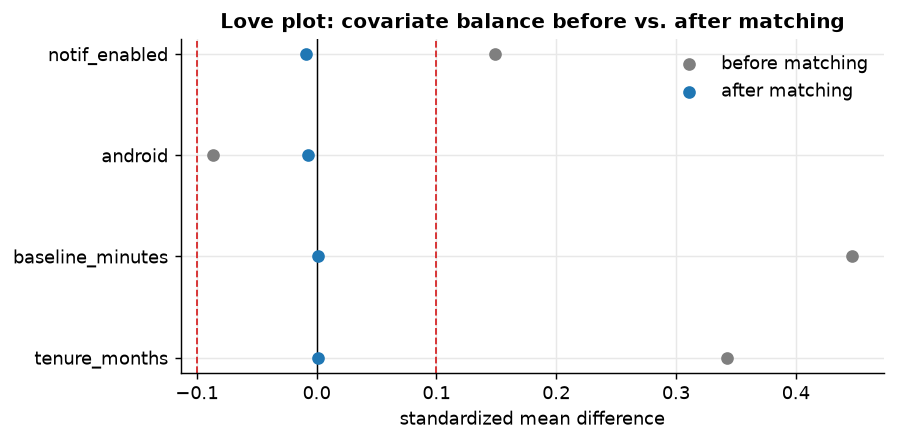

In [9]:
# ── Love plot: SMD before vs. after matching ──
fig, ax = plt.subplots(figsize=(7, 3.5))
y_pos = np.arange(len(covs))
ax.scatter(balance["smd_before"], y_pos, color="#7f7f7f", label="before matching", zorder=3)
ax.scatter(balance["smd_after_matching"], y_pos, color="#1f77b4", label="after matching", zorder=3)
ax.axvline(0, color="black", lw=0.8)
ax.axvline(0.1, color="#d62728", ls="--", lw=1)
ax.axvline(-0.1, color="#d62728", ls="--", lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(covs)
ax.set_xlabel("standardized mean difference")
ax.set_title("Love plot: covariate balance before vs. after matching")
ax.legend(); plt.tight_layout(); plt.show()

## The honest limit: unobserved confounding from self-selection

Matching and IPW only balance **observed** covariates. In this simulation,
`unobserved_interest` drives both opt-in and future engagement but was never available to the
propensity model — by construction, no amount of matching on tenure/baseline
minutes/device/notifications can remove its influence. Let's quantify the residual bias.

In [10]:
residual_bias = matched_att - true_effect
print(f"Matched ATT: {matched_att:.2f}   True effect: {true_effect}   Residual bias: {residual_bias:.2f}")
print("\nThe residual bias here comes entirely from `unobserved_interest`, which we deliberately")
print("excluded from the propensity model to mimic a real analyst's blind spot. Matching removed")
print("essentially all the bias from tenure/activity/device/notifications, but self-selection on an")
print("unobserved trait leaves a real gap between the matched estimate and the truth.")

Matched ATT: 16.91   True effect: 12.0   Residual bias: 4.91

The residual bias here comes entirely from `unobserved_interest`, which we deliberately
excluded from the propensity model to mimic a real analyst's blind spot. Matching removed
essentially all the bias from tenure/activity/device/notifications, but self-selection on an
unobserved trait leaves a real gap between the matched estimate and the truth.


This is exactly the scenario self-selected feature adoption creates in practice: users who
opt in are disproportionately the ones who *would have* engaged more anyway, for reasons a
typical event-logging schema does not capture (intrinsic curiosity, life circumstances,
concurrent unobserved behavior changes). Matching/IPW are only as good as the covariates fed
into them.

## Practitioner checklist

1. **List every plausible confounder of self-selection before estimating anything** — the
   credibility of matching lives or dies on this list, not on the matching algorithm.
2. **Check overlap first** — units with no comparable counterpart on the other side must be
   dropped or reweighted; do not extrapolate.
3. **Report the Love plot / SMD table** as a design diagnostic, computed with outcomes hidden.
4. **Cross-check matching against IPW (or AIPW)** — large disagreement between methods is a
   red flag about model specification, not just noise.
5. **Never claim "no unobserved confounding"** for a self-selection design — instead, run a
   sensitivity analysis (`causal_inference_course/12_sensitivity_analysis.ipynb`, e.g. Rosenbaum
   bounds or E-values) to quantify how strong an unobserved confounder would need to be to
   overturn the conclusion.
6. **Prefer a design with actual randomization when the stakes are high** — matching is a
   fallback for when an A/B test is genuinely infeasible, not a substitute for one when it isn't.

## Key takeaways

| Concept | Statement |
|---|---|
| Self-selection | Users who opt into a feature differ systematically from those who don't |
| Propensity score | Summarizes observed confounders into one balancing score |
| Matching / IPW | Both recover the causal effect *if* unconfoundedness holds on the observed covariates |
| Balance diagnostics | SMD / Love plots verify the design worked, computed without looking at outcomes |
| Fundamental limit | Unobserved confounders driving self-selection are never removed by matching |

## References

| Author(s) | Title | Role here |
|---|---|---|
| Rosenbaum & Rubin (1983, *Biometrika*) | "The Central Role of the Propensity Score" | Propensity score theory |
| Stuart (2010, *Statistical Science*) | "Matching Methods for Causal Inference: A Review" | Applied matching workflow |
| Imbens & Rubin (2015) | *Causal Inference for Statistics...*, Ch. 15, 17-18 | Balance diagnostics, overlap |
| Cunningham (2021) | *Causal Inference: The Mixtape*, Ch. 5 | Applied exposition |
